# Setup

For analyzing result of models trained based on cluster assignments

In [1]:
import os, sys, time

from pathlib import Path
import pickle 
import json 
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

import PyComplexHeatmap as pch
from PyComplexHeatmap import *

In [2]:
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score, precision_recall_curve
from scipy.stats import entropy
from itertools import combinations
from sklearn.metrics import mutual_info_score, confusion_matrix

/gale/netapp/home2/aklein/miniconda3/envs/agp/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/gale/netapp/home2/aklein/miniconda3/envs/agp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cell_types = ['L23_IT_CTX_Glut','L5_ET_CTX_Glut','L6_IT_CTX_Glut','L6_CT_CTX_Glut','CA3_Glut','CA1-ProS_Glut','DG_Glut','Astro-TE_NN','Oligo_NN','OPC_NN',]

# Functions

In [4]:
def information_gain(labels, preds): 
    start_entropy = entropy(pd.DataFrame(labels).value_counts(), base=2)
    ccf = confusion_matrix(labels, preds)
    conditional_entropy = (entropy(ccf, base=2, axis=0) * (ccf.sum(axis=0) / ccf.sum())).sum()
    return start_entropy - conditional_entropy 

def jaccard_similarity(set_1, set_2): 
    inter = len(set_1.intersection(set_2))
    union = len(set_1.union(set_2))
    return inter / union

In [6]:
def jaccard_corr_matrix(samples): 
    n_samples = len(samples)
    corr = np.zeros((n_samples,n_samples), dtype=np.float64)
    for i in range(n_samples): 
        for j in range(n_samples): 
            corr[i][j] = jaccard_similarity(samples[i], samples[j])
    return corr

In [7]:
def generate_rank_corr_matrix(cell_types:list, col:str='rank', num_downsample:int|None = None, filename:str="shap_rank"):
    """
    Separate out Results into their up / down / up
    cell_types - the cell types to do this for
    col - the column to extrac (rank / abs_mean_shap)
    """
    df_down = pd.DataFrame()
    df_non = pd.DataFrame()
    df_up = pd.DataFrame()
    for i, _ct in enumerate(cell_types):
        df_rank = pd.read_csv(f'../train_models/xgb_logging/{_ct}.{filename}.csv', index_col='index')
        
        if num_downsample is not None: 
            samp_rank = pd.DataFrame(df_rank.loc[df_rank[f'rank.down'] < num_downsample, f'{col}.down'])
            samp_rank = samp_rank.merge(df_rank.loc[df_rank[f'rank.non'] < num_downsample, f'{col}.non'], left_on='index', right_on = 'index', how='outer')
            samp_rank = samp_rank.merge(df_rank.loc[df_rank[f'rank.up'] < num_downsample, f'{col}.up'], left_on='index', right_on = 'index', how='outer')
            df_rank = samp_rank.copy()
            del samp_rank
    
        if i == 0: 
            df_down[_ct] = df_rank[f'{col}.down']
            df_non[_ct] = df_rank[f'{col}.non']
            df_up[_ct] = df_rank[f'{col}.up']
        else: 
            df_down = df_down.merge(df_rank[f'{col}.down'], left_on='index', right_on='index', how='outer')
            df_down[_ct] = df_down[f'{col}.down'] 
            df_down = df_down.drop(columns = [f'{col}.down'])
    
            df_non = df_non.merge(df_rank[f'{col}.non'], left_on='index', right_on='index', how='outer')
            df_non[_ct] = df_non[f'{col}.non'] 
            df_non = df_non.drop(columns = [f'{col}.non'])
    
            df_up = df_up.merge(df_rank[f'{col}.up'], left_on='index', right_on='index', how='outer')
            df_up[_ct] = df_up[f'{col}.up'] 
            df_up = df_up.drop(columns = [f'{col}.up'])    
    return (df_down, df_non, df_up)

def generate_mod_corr_matrix(cell_types:list, num_downsample:int|None = None, filename:str='shap_rank'):
    """
    Generate counts for the number of features in each data category in the top num_downsample most important
    feature for each classification category.
    cell_types - the cell types to do this for
    col - the column to extrac (rank / abs_mean_shap)
    """
    df_down = pd.DataFrame()
    df_non = pd.DataFrame()
    df_up = pd.DataFrame()
    for i, _ct in enumerate(cell_types):
        df_rank = pd.read_csv(f'../train_models/xgb_logging/{_ct}.{filename}.csv', index_col='index')
        
        if num_downsample is not None: 
            samp_rank = pd.DataFrame(df_rank.loc[df_rank[f'rank.down'] < num_downsample, f'rank.down'])
            samp_rank = samp_rank.merge(df_rank.loc[df_rank[f'rank.non'] < num_downsample, f'rank.non'], left_on='index', right_on = 'index', how='outer')
            samp_rank = samp_rank.merge(df_rank.loc[df_rank[f'rank.up'] < num_downsample, f'rank.up'], left_on='index', right_on = 'index', how='outer')
            df_rank = samp_rank.copy()
            del samp_rank

        mod_split = [x.split('.')[-1] for x in df_rank.index]
        if i == 0: 
            df_counts = pd.DataFrame(pd.DataFrame(mod_split).value_counts())
            df_counts.columns = [_ct]
        else: 
            df_counts[_ct] = pd.DataFrame(mod_split).value_counts()
    
    return df_counts.fillna(0)

In [8]:
def generate_modality_rankings(cell_type:str, ds:int|None=None, filename:str='shap_rank'):
    df_rank = pd.read_csv(f'../train_models/xgb_logging/{_ct}.{filename}.csv', index_col='index')
    df_rank['modality'] = [idx.split(".")[-1] for idx in df_rank.index]
    df_rank = df_rank.rename(columns = {"abs_mean_shap.down" : "-1", "abs_mean_shap.non": "0", "abs_mean_shap.up" : "1"}).drop(columns = ["rank.down", "rank.non", "rank.up"])
    return df_rank

def min_max_norm(df_rank):
    df_rank['1'] = (df_rank['1'] - df_rank['1'].min()) / (df_rank['1'].max() - df_rank['1'].min())
    df_rank['0'] = (df_rank['0'] - df_rank['0'].min()) / (df_rank['0'].max() - df_rank['0'].min())
    df_rank['-1'] = (df_rank['-1'] - df_rank['-1'].min()) / (df_rank['-1'].max() - df_rank['-1'].min())
    return df_rank

# Plotting Cluster trained accuracies

In [78]:
# Define a cluster pallete

In [138]:
cluster_palette =  {"CTX_Glut" : '#E63946',
                    "Hipo_Glut" : '#1D3557',
                    "NN" : '#2A9D8F',
                    "IT_CTX_Hipo_Glut" : '#9D4EDD',
                    "CTX_Hipo_Glut" : '#F1A208',
                    "NN_DG_Glut" : '#E377C2',
                    "rand" : '#8D8D8D'
                   }

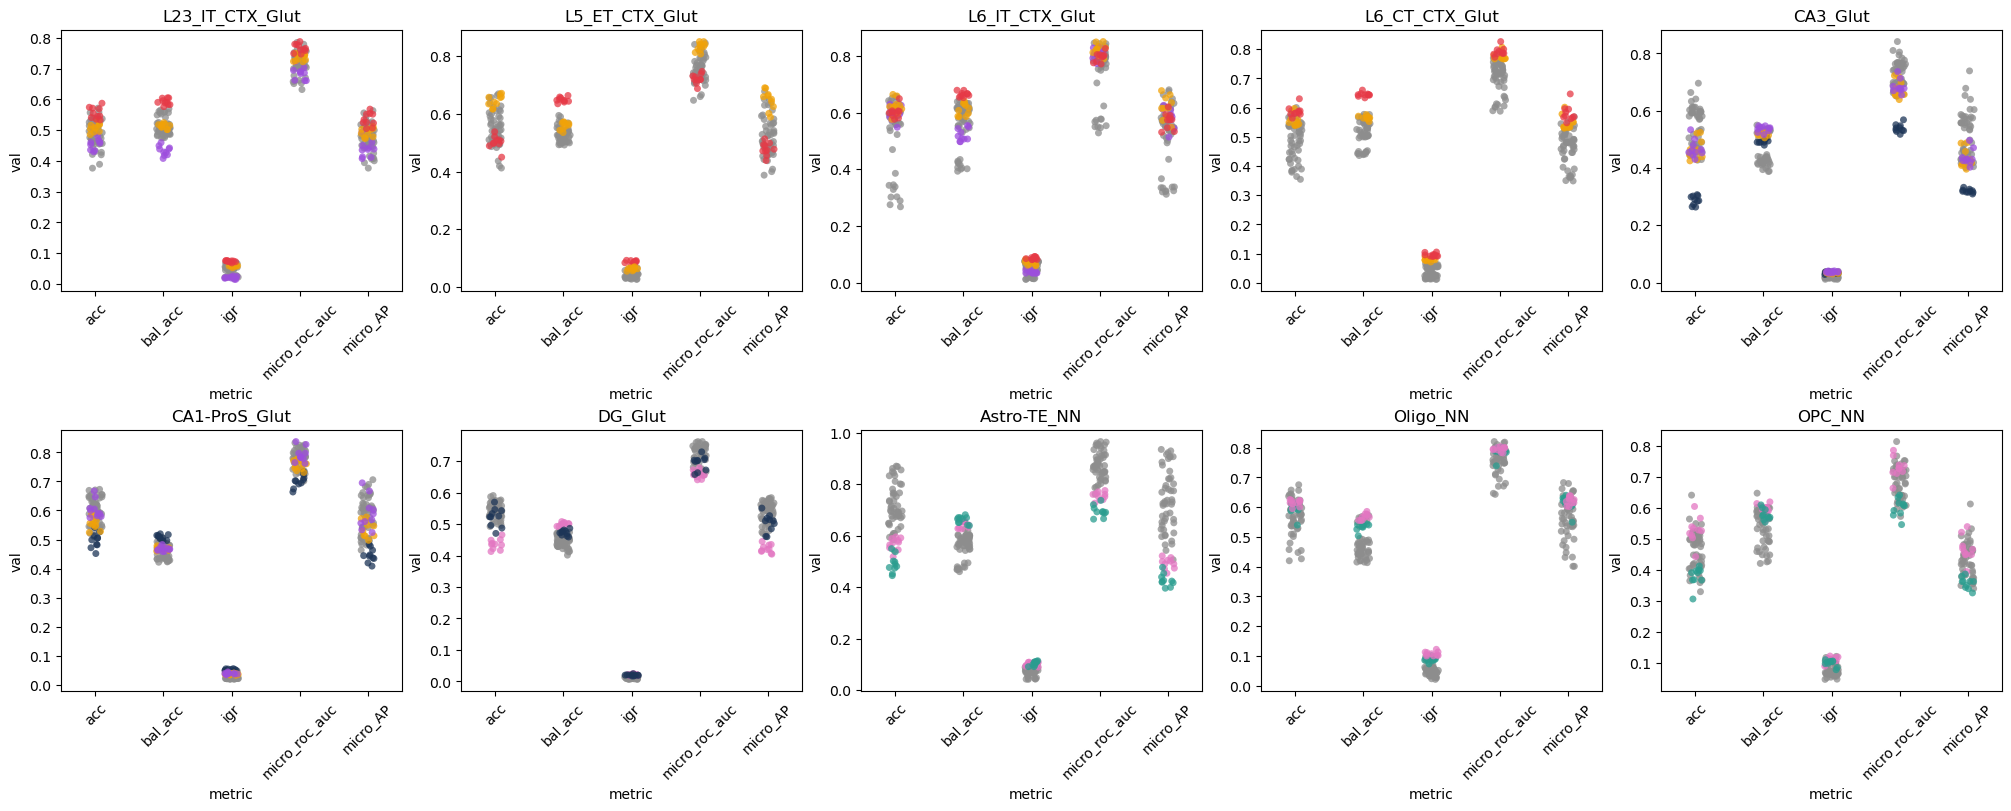

In [142]:
# The metrics to plot
metrics = ['acc', 'bal_acc', 'igr', 'micro_roc_auc', 'micro_AP']
accessors = metrics + ['clust_label']

# For plotting
fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)

# Iterating over cell types
for i, _ct in enumerate(cell_types): 
    # print(_ct)

    toplot = [] # The plotting list

    
    # For the random cluster results
    random_result_files = glob.glob(f'../result_data/xgb_mods/clust_rand_metrics/{_ct}.*.metrics.csv')
    for _file in random_result_files: 
        df_mets = pd.read_csv(_file, index_col=0)
        df_mets['clust_label'] = 'rand'# _file.split('/')[-1].split('.')[1]
        toplot.append(df_mets)
    
    # For the true cluster results
    cluster_result_files = glob.glob(f'../result_data/xgb_mods/clust_metrics/*.{_ct}.metrics.csv')
    for _file in cluster_result_files: 
        df_mets = pd.read_csv(_file, index_col=0)
        df_mets['clust_label'] = _file.split('/')[-1].split('.')[0]
        toplot.append(df_mets)

    toplot = pd.concat(toplot)
    toplot = toplot.melt(value_vars=metrics, id_vars='clust_label', var_name = 'metric', value_name='val')

    ax = axes.flatten()[i]
    sns.stripplot(toplot, x='metric', y='val', hue='clust_label', 
                  alpha=0.75, palette=cluster_palette, size=5, 
                  legend=False, ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(_ct)

plt.show()

In [112]:
legend_df = pd.DataFrame(cluster_palette.keys(), columns=['name'])
legend_df['x'] = 1
legend_df['y'] = 1
legend_df['c'] = cluster_palette.values()

In [98]:
toplot['clust_label'].unique()

array(['NN_DG_Glut', 'NN'], dtype=object)

In [129]:
import matplotlib.patches as mpatches

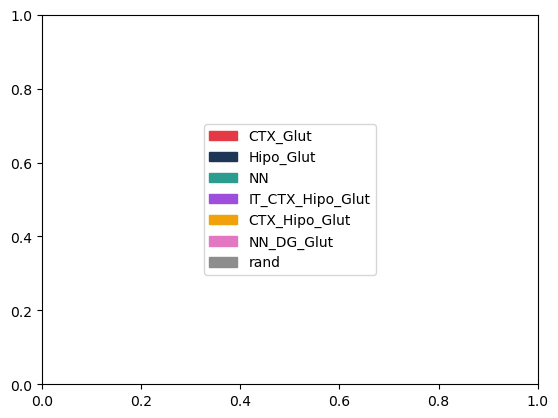

In [140]:
fig, ax = plt.subplots()
legend = []
for nn, cc in cluster_palette.items(): 
    legend.append(mpatches.Patch(color=cc, label=nn))
ax.legend(handles=legend, loc='center')
plt.show()

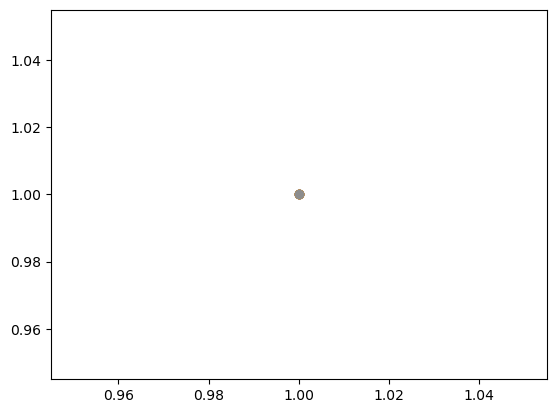

<Figure size 640x480 with 0 Axes>

In [122]:
fig = plt.figure()
legend_fig = plt.figure("Legend")
ax = fig.add_subplot(111)
handler = []; legend = [];
for row in legend_df.iterrows(): 
    ss = ax.scatter(data=row[1], x='x', y='y', c='c')
    handler.append(ss)
    legend.append(row[1]['name'])

legend_fig.legend(handler, legend, loc='center')
plt.show()

In [125]:
handler[0]

/gale/ddn/aging/aklein/240903_aging_mice/aging_gene_prediction/aging_gene_prediction/ak_workspace/analyze_results/ipykernel_69357/1601881017.py:1: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  legend = plt.legend(cluster_palette.values(), cluster_palette.keys(), loc=3, framealpha=1, frameon=True)


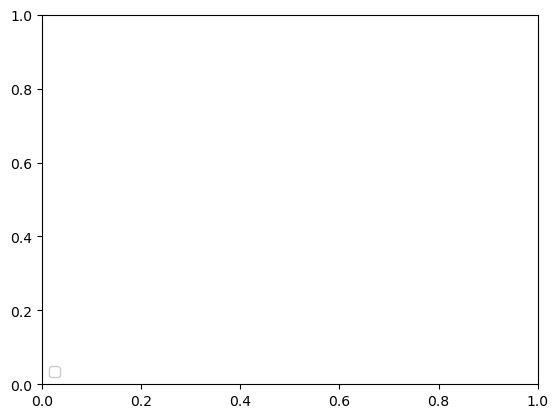

In [96]:



legend = plt.legend(cluster_palette.values(), cluster_palette.keys(), loc=3, framealpha=1, frameon=True)
legend.figure.canvas.draw()
plt.show()

In [67]:
# toplot

In [59]:
cluster_result_files = glob.glob(f'../result_data/xgb_mods/clust_metrics/*.{_ct}.metrics.csv')

In [61]:
toplot = []
for _file in cluster_result_files: 
    df_mets = pd.read_csv(_file, index_col=0)
    df_mets['clust_label'] = _file.split('/')[-1].split('.')[0]
    toplot.append(df_mets

'IT_CTX_Hipo_Glut'

In [19]:
df_mets = pd.read_csv('../result_data/xgb_mods/clust_metrics/CTX_Glut.L23_IT_CTX_Glut.metrics.csv', index_col=0)
df_mets['clust_label'] = 'CTX_Glut'
df_rand_mets = pd.read_csv('../result_data/xgb_mods/clust_rand_metrics/L23_IT_CTX_Glut.rand_0.metrics.csv', index_col=0)
df_rand_mets['clust_label'] = 'rand'

In [16]:
df_rand_mets.bal_acc

0    0.501259
1    0.499207
2    0.493279
3    0.486379
4    0.475706
5    0.475164
6    0.483248
7    0.488134
8    0.488050
9    0.490356
Name: bal_acc, dtype: float64

In [37]:
metrics = ['acc', 'bal_acc', 'igr', 'micro_roc_auc', 'micro_AP']
accessors = metrics + ['clust_label']
print(accessors)
toplot = pd.concat((df_mets[accessors], df_rand_mets[accessors] ))

['acc', 'bal_acc', 'igr', 'micro_roc_auc', 'micro_AP', 'clust_label']


In [46]:
toplot = toplot.melt(value_vars=metrics, id_vars='clust_label', var_name = 'metric', value_name='val')

<Axes: xlabel='metric', ylabel='val'>

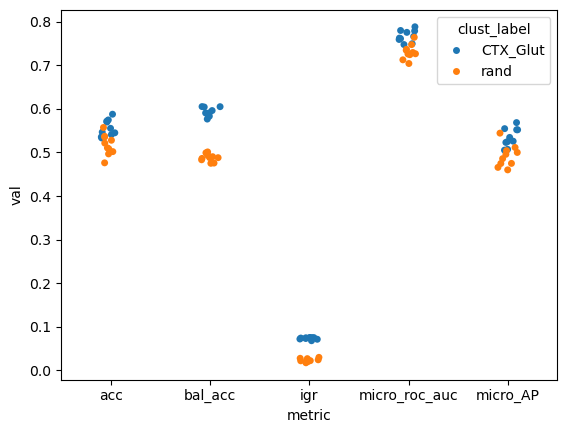

In [49]:
sns.stripplot(toplot, x='metric', y='val', hue='clust_label')